### 영상처리를 위한 딥러닝 - 1

In [26]:
import tensorflow as tf
tf.__version__

'2.10.0'

#### set_log_device_placement
- 연산과 텐서가 어떤 장치(CPU/GPU)에 할당되었는지 확인
- 활성화하면 모든 텐서나 연산 할당이 출력
- GPU 있는 사람들에게 유용, 처리 속도는 느려짐

In [2]:
# tf.debugging.set_log_device_placement(True) # 활성화 

- 데이터를 가져와야함
- tf, pytorch는  Numpy와 호환이 잘 되나 Numpy에서 tensor로 바꾸는데 overhead생김

In [3]:
dir(tf)   # Numpy와 호환됨 -수많은 subpackage로 구성됨

['AggregationMethod',
 'Assert',
 'CriticalSection',
 'DType',
 'DeviceSpec',
 'GradientTape',
 'Graph',
 'IndexedSlices',
 'IndexedSlicesSpec',
 'Module',
 'Operation',
 'OptionalSpec',
 'RaggedTensor',
 'RaggedTensorSpec',
 'RegisterGradient',
 'SparseTensor',
 'SparseTensorSpec',
 'Tensor',
 'TensorArray',
 'TensorArraySpec',
 'TensorShape',
 'TensorSpec',
 'TypeSpec',
 'UnconnectedGradients',
 'Variable',
 'VariableAggregation',
 'VariableSynchronization',
 '_API_MODULE',
 '_LazyLoader',
 '__all__',
 '__builtins__',
 '__cached__',
 '__compiler_version__',
 '__cxx11_abi_flag__',
 '__doc__',
 '__file__',
 '__git_version__',
 '__internal__',
 '__loader__',
 '__monolithic_build__',
 '__name__',
 '__operators__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_api',
 '_compat',
 '_current_file_location',
 '_current_module',
 '_distutils',
 '_estimator_module',
 '_fi',
 '_initializers',
 '_inspect',
 '_keras',
 '_keras_module',
 '_keras_package',
 '_kernel_dir',
 '_ll',
 '_l

### 연습용 데이터
- keras.datasets
    - 전통적인 방법: 데이터 Numpy형태
        - 흑백 mnist, fashion_mnist 
        - 컬러 cifar10,cifar100  
        https://m.blog.naver.com/PostView.naver?isHttpsRedirect=true&blogId=qbxlvnf11&logNo=221295867121
- tensorflow_datasets
    - https://www.tensorflow.org/datasets?hl=ko
- AI hub

In [4]:
tf.keras.datasets.mnist

<module 'keras.api._v2.keras.datasets.mnist' from 'c:\\MyCursorLab\\tf210\\.venv\\lib\\site-packages\\keras\\api\\_v2\\keras\\datasets\\mnist\\__init__.py'>

In [5]:
len(tf.keras.datasets.mnist.load_data()) # 2개로 unpacking가능

2

## Sub Sampling
- resmapling의 하나로 중복을 허용하지 않는 샘플링 기법
### holdout 기법
- 데이터가 많은 경우 데이터를 나누어 데이터 기반의 주관적 성능 측정을 위해서 생성된 모델로 검증
    - 2-way :train,test
        - train: 모델 학습에 사용되는 훈련 세트
        - test: 모델 검정을 위한 unseen data에 대한 일반화된 성능 측정 
    - 3-way : train,test, validation
        - validation set: hyperparameter tunning을 목적으로 train 데이터에서 가져옴
            - `keras` 내부적으로 3way 자체적 제공
       
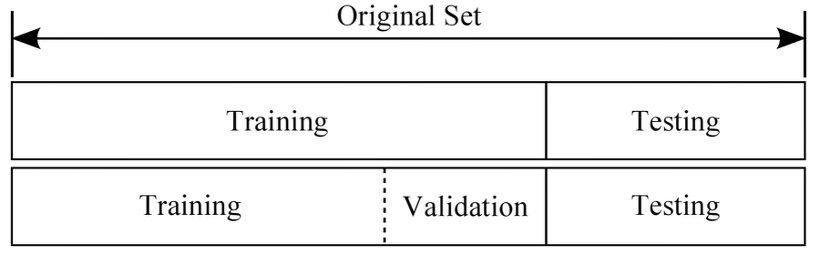
        
- 하이퍼파라미터를 가지고 hold-out하지 않고 **가용할 수 있는 모든 데이터로 최종 학습**
- 샘플이 독립적이고 동일한 분포를 갖는다는 i.i.d (independent and identically distributed) 가정
    - 가정에 의해 전체 데이터를 다시 최종학습에 사용하면 일반화 성능이 더 좋아짐 
   > 데이터가 적은 경우 cross-validation
### 분할 비율
- 데이터가 아주 많으면 큰 문제는 없지만 데이터가 작은경우에 분할 비율이 문제가 됨
  - bias vs variance trade-off
    - 비관적 편향: train set < test set
        - 모델이 미처 최대 성능 한계에 도달하지 않음
    - test data가 적으면 오차에 따라서 정확도에대한 분산도 커짐

- shuffle 랜덤하게 데이터 순서를 섞어서 독립성 보장


Bias는 데이터 내에 있는 모든 정보를 고려하지 않음으로 인해, 지속적으로 잘못된 것들을 학습하는 경향을 말한다. underfitting 이라고도 한다.

반대로 Variance는 데이터 내에 있는 에러나 노이즈까지 잘 잡아내는 highly flexible models 에 데이터를 fitting시킴으로써, 실제 현상과 관계 없는 random한 것들까지 학습하는 알고리즘의 경향을 의미한다. 이는 overfitting과 관계되어 있다.

https://bywords.tistory.com/entry/%EB%B2%88%EC%97%AD-%EC%9C%A0%EC%B9%98%EC%9B%90%EC%83%9D%EB%8F%84-%EC%9D%B4%ED%95%B4%ED%95%A0-%EC%88%98-%EC%9E%88%EB%8A%94-biasvariance-tradeoff 

### stratification
- 계층적 샘플링(층화 계층)
- train,test의 데이터셋의 각 클래스의 분포의 균형을 맞추어 추정이 더 좋아짐 
> 큰 수의 법칙
    - 데이터가 많으면 원래 자기 분포에 가까워짐
    - iris 150개 중 3개의 class가 각 50개 씩 있음 (분포를 맞춤)

In [6]:
import numpy as np

In [7]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data() # unpacking

In [8]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [9]:
# np.unique : 고유한 원소를 정렬, 아래는 count(갯수)도 반환
np.unique(y_train,return_counts=True) # 60,000개 중 어느 정도 분포를 6,000개 안팎으로 비슷하게 맞춤

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949],
       dtype=int64))

In [10]:
np.unique(y_test,return_counts=True) # 10,000개 test도 거의 맞춰줌

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009],
       dtype=int64))

### data leackage
- 데이터 누수(유출)
- 훈련 데이터에 테스트 데이터가 일부 섞이는 경우 발생
    - 중복 데이터 제거
    - 이미지는 고차원이므로 동일한 데이터이기 힘듦
- 낙관적 편향: 학습에 사용한 훈련데이터로 모델 평가하는 재치환 평가(resubstitution evaluation)하거나  
테스트 데이터를 여러번 재사용 하면 낙관적으로 일반화 성능 추정 
    - 과대적합으로 편향 감소하면서 분산 증가  
https://m.blog.naver.com/PostView.naver?isHttpsRedirect=true&blogId=tjdudwo93&logNo=221085844907    

### data shift
- 학습과 테스트 데이터셋의 특성이 다른 경우  
학습데이터와 테스트 데이터에서의 인풋과 아웃풋의 joint distribution가 다른 경우를 의미한다.  
학습데이터셋과 테스트셋의 분포가 다른 경우, 예를 들어, 얼굴 인식 모델에서, 학습데이터는 어린 아이들이  
대부분인 데이터로 하고, 테스트셋은 노인들이 대부분인 데이터로 하는 경우   
https://velog.io/@jkl133/Understanding-Dataset-Shift

### 모델 평가
- ML/DL에서는 절대적인 수치의 성능을 만드는것은 어려움
- random sampling - 각각의 요소 또는 사례들이 표본(sample)으로 선택될 가능성이 같게 되는 표본 추출법  
전체를 대표는 할 수는 있다

몬테카를로 sampling:
- 반복된 무작위 추출(repeated random sampling)을 이용  
- 동일한 데이터를  랜덤하게 k번 분리해서 k개 모델을 만들어 성능 측정 

## Learning Curve
- 모델이 학습이 잘 되고 있는지 진단
- x축에 따라y축 바뀜

- train 학습여부 판단, validation unseen 데이터 통해서 일반화 성능 체크,unseen data:학습에 사용되지 않은 데이터


1. 데이터 크기별로
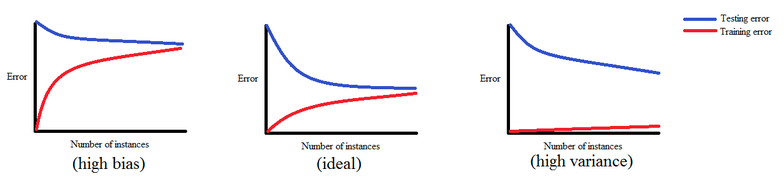
    - 데이터의 크기에 따라서 어떻게 변하는지
        - 데이터 적은 경우 : spark/jittering 있으면 분산이 큼 ->  cross validation 
        - underfiting:  validation > train,  train > validation
        - overfitting : validation > train
        - 최적의 모델: train, test score 차이 없으면서 loss 작음 
    - train score: 일반화되면서 과대적합이 감소하면서 감소됨
    - test score: 훈련세트 크기가 커질수록 일반화 정확도 향상  
https://heytech.tistory.com/125  
2. epochs 별로 
    - 딥러닝 기법
        - 과소적합
        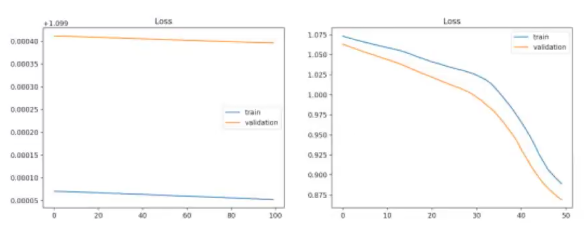
        - 과대적합
        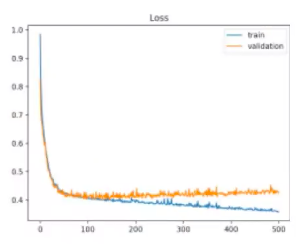
        - 최적
        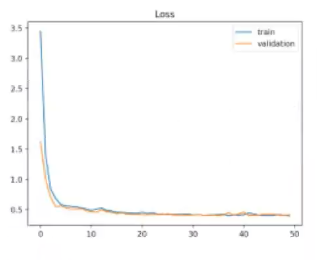
         - test 데이터가 적은 경우
        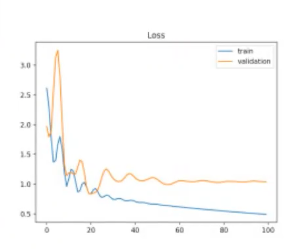
        - test 데이터가 적은 경우
        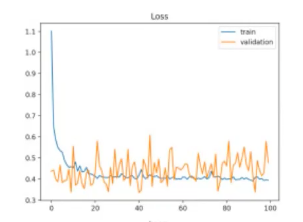

> tensorboard 그래프가 learning curve


### cross validation technique
 - 데이터 양이 적은 경우 학습 가능, 딥러닝에 사용됨
     - 데이터가 많다고 가정
     - k개를 연산, 시간이 오래걸림
 - 어느정도 데이터가 이 정도 같으면 되는지를 추정함
 - overfiting 예측 가능   
 https://incomeplus.tistory.com/245
 

Sequential 모델 작동 파악

In [11]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
model.fit(X_train,y_train,epochs=5,validation_split=0.3)

Epoch 1/5
1313/1313 [==============================] - 7s 4ms/step - loss: 3.4568 - accuracy: 0.7356 - val_loss: 0.6368 - val_accuracy: 0.8343
Epoch 2/5
1313/1313 [==============================] - 5s 4ms/step - loss: 0.6930 - accuracy: 0.8145 - val_loss: 0.4535 - val_accuracy: 0.8875
Epoch 3/5
1313/1313 [==============================] - 5s 4ms/step - loss: 0.5371 - accuracy: 0.8564 - val_loss: 0.3670 - val_accuracy: 0.9138
Epoch 4/5
1313/1313 [==============================] - 6s 4ms/step - loss: 0.4747 - accuracy: 0.8755 - val_loss: 0.3454 - val_accuracy: 0.9209
Epoch 5/5
1313/1313 [==============================] - 6s 4ms/step - loss: 0.4406 - accuracy: 0.8857 - val_loss: 0.3942 - val_accuracy: 0.9211


In [13]:
model.history.history

{'loss': [3.4567558765411377,
  0.6930497288703918,
  0.5370955467224121,
  0.47473540902137756,
  0.44055888056755066],
 'accuracy': [0.7355714440345764,
  0.8144761919975281,
  0.8564285635948181,
  0.8754523992538452,
  0.8857380747795105],
 'val_loss': [0.6367568969726562,
  0.45349523425102234,
  0.3670363128185272,
  0.3454006612300873,
  0.3942432105541229],
 'val_accuracy': [0.8342777490615845,
  0.887499988079071,
  0.913777768611908,
  0.9208889007568359,
  0.9211111068725586]}

In [14]:
# !pip install pandas
# !pip install matplotlib
import pandas as pd
import pandas


pd.DataFrame(model.history.history)

,loss,accuracy,val_loss,val_accuracy
0,3.456756,0.735571,0.636757,0.834278
1,0.693050,0.814476,0.453495,0.887500
2,0.537096,0.856429,0.367036,0.913778
3,0.474735,0.875452,0.345401,0.920889
4,0.440559,0.885738,0.394243,0.921111


<Axes: >

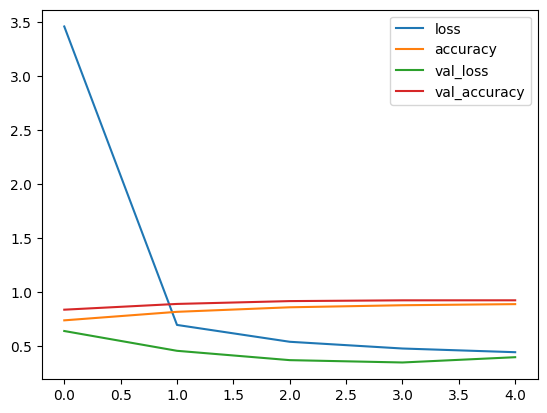

In [15]:
pd.DataFrame(model.history.history).plot.line() # underfiting 되어 있음 

##  모델 만드는법
5가지
- 혼합 사용 가능 
    1. tensor : tf.nn.xxx ,  pytorch에서 차용
    2. estimator :  scikit-learn으로 부터 차용    
        - 고수준으로 만들어진것, GPU 지원
        - 하위 호환성을 위해 남겨둠  
        https://www.tensorflow.org/guide/estimator
    3. Keras Sequential
    4. Keras Model
        - (OOP+FP)
            - 재사용, 확장성
    5. Keras subclass model
      -  tf2에서 서로 거의 연동되지만 tf1과는 호환이 안되기 때문에 
        - 고수준이지만 확장가능성이 많으며 이론과 현실 격차를 줄임
        - 저수준인 tensor로 모든것을 할 필요가 없음
        - 객체지향 방식으로 keras model로 만듦
            - 단순한 객체지향 아님  
            https://wikidocs.net/106897


### Sequential 
- (OOP 객체지향, Declarative)
    - 재사용
    - 선언에 따라서 모델 실행
    - Feed Forward: 앞에서부터 레이어의 값 전달
    - layer전체를 한꺼번에 관리하는 추상적인 container
   - pytroch의 sequential과 비슷함  
   https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html

In [16]:
model =  tf.keras.Sequential()

In [17]:
dir(model)  # layers 를 add,build(구축),compute, fit(학습), predict

['_SCALAR_UPRANKING_ON',
 '_TF_MODULE_IGNORED_PROPERTIES',
 '__annotations__',
 '__call__',
 '__class__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_activity_regularizer',
 '_add_trackable',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_assert_compile_was_called',
 '_assert_weights_created',
 '_auto_track_sub_layers',
 '_autocast',
 '_autographed_call',
 '_base_model_initialized',
 '_build_graph_network_for_inferred_shape',
 '_build_input_shape',
 '_call_spec',
 '_callable_losses',
 '_captured_weight_regularizer',
 '_cast_single_input',
 '_check_call_args',
 '_check_sample_weight_warning',
 '_c

구축
- add

In [18]:
model = tf.keras.Sequential()
layer1 = tf.keras.layers.Dense(64)
model.add(layer1)

In [19]:
model.layers  # list형태로 보여줌

In [20]:
layer1

In [21]:
model.pop()   # transfer learning에서 간혹 사용
model.layers

[]

In [22]:
model = tf.keras.Sequential(
    tf.keras.layers.Dense(64)
)

In [23]:
model.layers

행렬곱에서 첫 번쨰와 마지막의 행렬 크기가 제일 중요함

In [24]:
model=tf.keras.Sequential()

layer1 = tf.keras.layers.Dense(64,input_shape=(28*28,)) # 입력 레이어 데이터를 1차원으로 입력 받음
layer2 = tf.keras.layers.Dense(10)

In [25]:
model.add(layer1)
model.add(layer2)
model.layers

In [26]:
tf.keras.backend.clear_session()  # 모델 기록된 거를 모두 삭제

 관례상 tuple로 표현

In [27]:
model=tf.keras.Sequential()
layer1= tf.keras.layers.Dense(64, input_shape=(28*28,),name='layer1')# 입력 레이어데이터 1차원으로 입력 받음
layer2= tf.keras.layers.Dense(10, name='layer2')

In [28]:
model.add(layer1)
model.add(layer2)
model.layers

input layer Flatten 시키는법

In [29]:
X_train.reshape(-1,28*28).shape  # layer에 입력하기 전에 처리 

(60000, 784)

In [30]:
model = tf.keras.Sequential()

flatten = tf.keras.layers.Flatten(input_shape=(28,28))            # layer에서 처리
layer1 = tf.keras.layers.Dense(64,name='layer1',activation='relu')
layer2 = tf.keras.layers.Dense(10, name='layer2')
activa = tf.keras.layers.Activation('softmax')

In [31]:
model.add(flatten)
model.add(layer1)
model.add(layer2)
model.add(activa)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 layer1 (Dense)              (None, 64)                50240     
                                                                 
 layer2 (Dense)              (None, 10)                650       
                                                                 
 activation (Activation)     (None, 10)                0         
                                                                 
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
_________________________________________________________________


한번에 모양 만들기
- declaration 중요

In [32]:
model=tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=[28,28]),
    tf.keras.layers.Dense(64,name='layer1',activation=tf.nn.relu),
    tf.keras.layers.Dense(10, name='layer2',activation='softmax' ),
    ])

- flatten 학습 안 함
- Param # 학습할 갯수 
- declaration 과정을 통해서 topology  모양에 따라 할 수 있는게 달라짐
 
- flatten 안, 밖에 할지 정할수 있는데 연산량 문제로 밖에 두는경우도 많음

activation 은 함수형 패러다임 
- 함수 , string을 넣어도 똑같이 작동함
    - tf.nn.relu == 'relu'
    > duck typing  
    https://nesoy.github.io/articles/2018-02/Duck-Typing

In [33]:
type(tf.nn.relu),type('relu')

(function, str)

In [35]:
# ! pip install pydot
# ! pip install graphviz 

anaconda prompt   
`conda install graphviz`

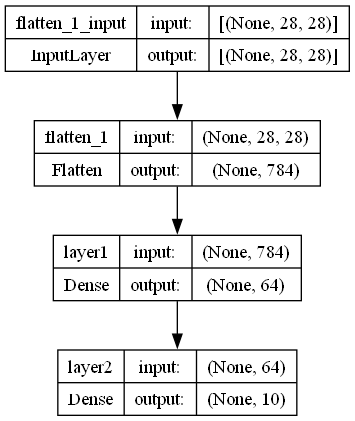

In [36]:
tf.keras.utils.plot_model(model,show_shapes=True) #모델 시각화

## compile
### loss
- 목적 : loss 함수 최소화
- 문제 정의에 따라 loss 바뀜
    - 이진분류: `binary_crossentropy`
    - 다중분류(one-hot encoding):`categorical_crossentropy`
    - 다중분류(label encoding):`sparse_categorical_crossentropy`
        * sparse matrix:희소행렬 : 행렬 내에 0 이 많음
-  기법을 만들기 위해서는 이해 필요


### optimizer
- 문제 해결 방식
    - learning rate
    - gradient descent
    
    
    모델의 목적에 따라서 평가 metric이 바뀜
      
    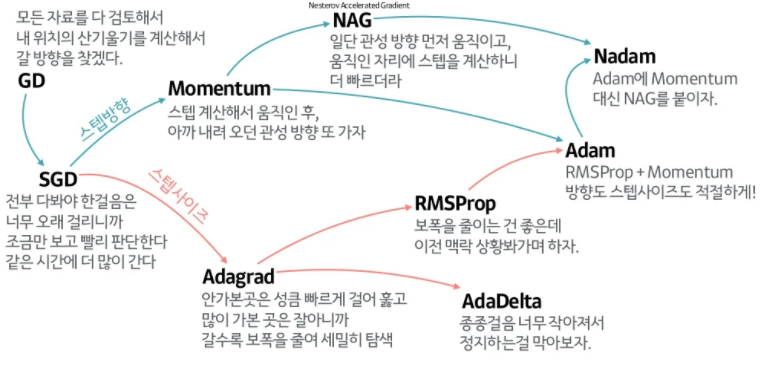

In [37]:
model.compile(loss='sparse_categorical_crossentropy',  # Y값을 one-hot인코딩 하지 않고 입력
              optimizer='adam',
              metrics=['acc'])            

In [38]:
model.fit(X_train,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 5s 2ms/step - loss: 2.0890 - acc: 0.7493
Epoch 2/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.5042 - acc: 0.8685
Epoch 3/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3549 - acc: 0.9059
Epoch 4/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2960 - acc: 0.9237
Epoch 5/5
1875/1875 [==============================] - 5s 2ms/step - loss: 0.2636 - acc: 0.9295


## 성능 향상을 위한 전처리: 정규화
### MinMaxscaler
- 전처리 2가지인  필수적인 전처리와 성능 높이기 위한 전처리가 있는데 정규화는 후자
    - 정규화 0~1사이의 값으로 변환함
    -  $ \frac{x-Min}{Max-Min}$
    - 신경망은 태생적으로 0~1 의 값으로 넣으면 gradient descent이용 해서 최소값 찾음
        -  정규화 하면 더 연산 속도가 빨라짐
        - 이미지는 정규화 하여도 특성 안바뀜

In [39]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data() # unpacking
X_train,X_test = X_train / 255 , X_test / 255

In [40]:
model=tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=[28,28]),
    tf.keras.layers.Dense(64,name='layer1',activation=tf.nn.relu),
    tf.keras.layers.Dense(10, name='layer2',activation='softmax' ),
    ])

In [41]:
model.compile(loss='sparse_categorical_crossentropy',  
              optimizer='adam',
              metrics=['acc'])    

In [42]:
model.fit(X_train,y_train,epochs=5)  # 60000/32=1875, 1 epoch에 1875회 학습

Epoch 1/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2988 - acc: 0.9165
Epoch 2/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1466 - acc: 0.9574
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.1048 - acc: 0.9688
Epoch 4/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0825 - acc: 0.9757
Epoch 5/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0677 - acc: 0.9797


fit output : <tensorflow.python.keras.callbacks.History at 0x7fd92aefde90>
- return이 있어서 할당 가능

메모리에 따라서 batch size 다르게 설정해서 학습, default:32

In [43]:
history = model.fit(X_train,y_train,epochs=3)

Epoch 1/3
1875/1875 [==============================] - 5s 2ms/step - loss: 0.0552 - acc: 0.9827
Epoch 2/3
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0488 - acc: 0.9854
Epoch 3/3
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0413 - acc: 0.9872


In [44]:
history.history   # epcoh 3개의 각 loss ,acc

{'loss': [0.055180177092552185, 0.04876718670129776, 0.04132170230150223],
 'acc': [0.9827166795730591, 0.9854166507720947, 0.9872000217437744]}

<Axes: >

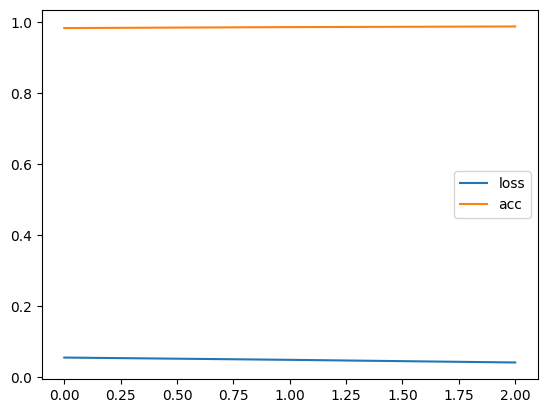

In [45]:
import pandas as pd
pd.DataFrame(history.history)
pd.DataFrame(history.history).plot.line() #범위가 작아서 이렇게 나옴..

loss  
accuracy =1 ,
- 100%맞는다는 의미인데 -> overfiting
- fit 할떄마다 기존의 loss부터 시작함

In [46]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.0800 - acc: 0.9769


[0.0799645483493805, 0.9768999814987183]

In [47]:
tf.keras.callbacks.ReduceLROnPlateau() # 고원현상 , learning rate decay  --> AlexNet(2012년) 에서 다룸

- early stopping등으로 loss의 크기 변화가 크지 않으면 멈춤

- local minima ,saddle point(안장점)에도 0 이 되는 지점이 있음
    - DL은 수백개의 파라미터가 동시에 0 나오기 힘듦  
 https://variety82p.tistory.com/entry/Local-Minima-%EB%AC%B8%EC%A0%9C%EC%97%90%EB%8F%84-%EB%B6%88%EA%B5%AC%ED%95%98%EA%B3%A0-%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%9D%B4-%EC%9E%98-%EB%90%98%EB%8A%94-%EC%9D%B4%EC%9C%A0%EB%8A%94  
---
## Scikit

### mpg

In [4]:
# !pip install seaborn

In [27]:
import seaborn as sns
mpg=sns.load_dataset('mpg')
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [28]:
origin=mpg.pop('origin') #m utable 자기자신 바뀌고 결과값 나옴

In [29]:
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,name
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,ford ranger


In [30]:
origin

0         usa
1         usa
2         usa
3         usa
4         usa
        ...  
393       usa
394    europe
395       usa
396       usa
397       usa
Name: origin, Length: 398, dtype: object

### iris

pop
- mutable method
    -  자기자신 바뀌고 return 있음
    - data, target 구분

In [31]:
iris= sns.load_dataset('iris')
iris_species=iris.pop('species')  #y값 

In [32]:
iris   #feature

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [33]:
iris.sample(frac=0.8) #80%의 데이터를 랜덤하게 뽑음  150->120

,sepal_length,sepal_width,petal_length,petal_width
10,5.4,3.7,1.5,0.2
121,5.6,2.8,4.9,2.0
120,6.9,3.2,5.7,2.3
14,5.8,4.0,1.2,0.2
57,4.9,2.4,3.3,1.0
...,...,...,...,...
36,5.5,3.5,1.3,0.2
138,6.0,3.0,4.8,1.8
109,7.2,3.6,6.1,2.5
72,6.3,2.5,4.9,1.5


In [34]:
# !pip install scikit-learn

In [35]:
from sklearn.model_selection import train_test_split

train_test_split
- 기본적으로 순서 섞어서 train,test 분할
- 층화샘플링은 옵션으로 선택

In [36]:
test,train= train_test_split(iris.iloc[:,:-1],
                            test_size=0.9) #unpacking

In [37]:
train   # 150 -> 135

,sepal_length,sepal_width,petal_length
97,6.2,2.9,4.3
51,6.4,3.2,4.5
138,6.0,3.0,4.8
103,6.3,2.9,5.6
108,6.7,2.5,5.8
...,...,...,...
56,6.3,3.3,4.7
19,5.1,3.8,1.5
84,5.4,3.0,4.5
8,4.4,2.9,1.4


In [38]:
test

,sepal_length,sepal_width,petal_length
77,6.7,3.0,5.0
7,5.0,3.4,1.5
80,5.5,2.4,3.8
124,6.7,3.3,5.7
116,6.5,3.0,5.5
96,5.7,2.9,4.2
12,4.8,3.0,1.4
6,4.6,3.4,1.4
99,5.7,2.8,4.1
34,4.9,3.1,1.5


In [39]:
test,train= train_test_split(iris.iloc[:,:-1],
                            test_size=0.9,shuffle=False) #순서대로

In [40]:
train

,sepal_length,sepal_width,petal_length
15,5.7,4.4,1.5
16,5.4,3.9,1.3
17,5.1,3.5,1.4
18,5.7,3.8,1.7
19,5.1,3.8,1.5
...,...,...,...
145,6.7,3.0,5.2
146,6.3,2.5,5.0
147,6.5,3.0,5.2
148,6.2,3.4,5.4


In [41]:
 X_train,X_test,y_train,y_test=train_test_split(iris.iloc[:,:-1],iris_species) 

In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112 entries, 18 to 67
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  112 non-null    float64
 1   sepal_width   112 non-null    float64
 2   petal_length  112 non-null    float64
dtypes: float64(3)
memory usage: 3.5 KB


In [43]:
y_train.value_counts() #갯수 안맞음

species
setosa        41
versicolor    36
virginica     35
Name: count, dtype: int64

In [44]:
# X_train.value_counts()

In [45]:
 X_train,X_test,y_train,y_test=train_test_split(iris.iloc[:,:-1],iris_species,
                                               stratify=iris_species) 
# stratify : 분포를 원본과 동일하게 split!! , balanced dataset으로 쪼개진다

In [46]:
y_train.value_counts() #class별로  balanced data 

species
setosa        38
versicolor    37
virginica     37
Name: count, dtype: int64

tf 연습용 데이터에서도 사용가능

In [47]:
(X_train, y_train),_= tf.keras.datasets.mnist.load_data()

In [48]:
print(X_train.shape)
data=X_train.reshape(-1,28*28) #1 차원화

(60000, 28, 28)


In [49]:
 X_train,X_test,y_train,y_test=train_test_split(data,X_train,
                                               stratify=y_train)  # 0.75:0.25

In [50]:
X_train = X_train.reshape(-1,28,28)

In [51]:
# 랜덤하게 인덱싱
X_train[[0,1,2]]  #fancy indexing

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint8)

stratify 쉽게 하기엔 힘듦
각 클래스별로 sampling 해야해서 번거로움

In [52]:
import numpy as np
np.where(y_train==1) # 1인값만 추출 

(array([    0,     0,     4, ..., 44995, 44996, 44997], dtype=int64),
 array([ 5, 22,  4, ..., 12,  6, 10], dtype=int64),
 array([10, 17, 23, ..., 20, 18, 17], dtype=int64))

---
## fashion_mnist
### Keras를 사용한 ML 기본사항 
### 기본 이미지 분류 
참고 : https://www.tensorflow.org/tutorials/keras/classification?hl=ko
- fashion item 10가지
- 연습용 데이터는 hold-out되어 잇음 

- `load_data()` 함수를 호출하면 네 개의 넘파이(NumPy) 배열이 반환

- 모델 학습에 사용되는 훈련 세트: X_train,y_train
- 모델 테스트에 사용되는 테스트 세트 :X_test,y_test

In [4]:
(X_train, y_train), (X_test,y_test)=tf.keras.datasets.fashion_mnist.load_data() 

In [5]:
import matplotlib.pyplot as plt

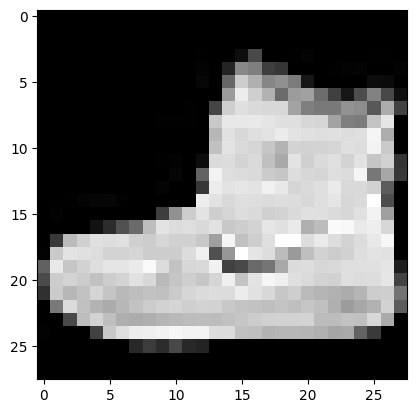

In [6]:
plt.imshow(X_train[0],cmap='gray')

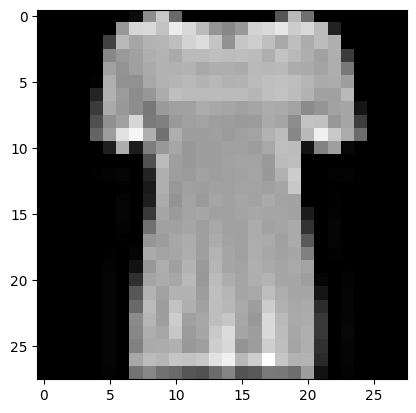

In [7]:
plt.imshow(X_train[10],cmap='gray')

- 이미지 크기 : 28x28 크기의 넘파이 배열
- 픽셀 값: 0~ 255(흑백이미지)

In [8]:
X_train.shape  , X_test.shape

((60000, 28, 28), (10000, 28, 28))

1. 머신러닝 관점에서 데이터 확보
2. 데이터 갯수 알고 있음
3. 데이터 EDA(Exploratory Data Analysis) 탐색적 데이터 분석
4. 6:1 로 데이터 비율 분할  
https://www.tensorflow.org/tutorials/keras/classification?hl=ko

In [13]:
import numpy as np
import pandas as pd
np.unique(y_train,return_counts=True) # 총 10개의 items 가 각 6,000개씩 있음 (balanced data)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000],
       dtype=int64))

In [14]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#### Label Encoding
- label: 0에서 9까지의 정수 배열 
- classs: 이미지에 있는 classs

In [15]:
x,y=np.unique(y_train, return_counts=True)
data=pd.DataFrame(y.reshape(1,-1), columns=class_names)

In [16]:
data

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000


### EDA
- 각 클래스별로 갯수 비교하여 전체적 비율 확인

<Axes: >

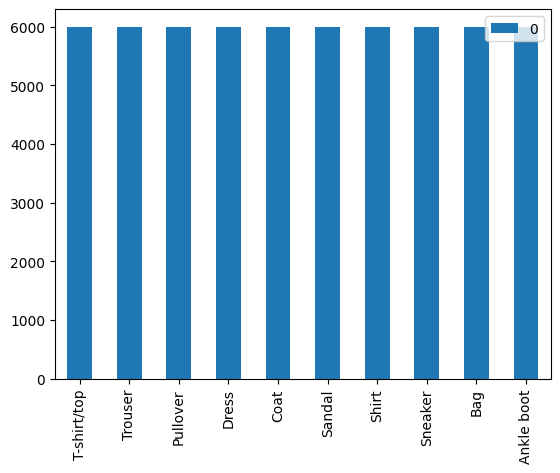

In [17]:
data.T.plot.bar() # balacned

 MinMaxScaler
- 0~255

In [18]:
X_train=X_train/255 
X_test=X_test/255

#### Imbalanced dataset
- 수량이 더 많은 class 더 학습 성능이 좋음 
- compile( metrics=  precision, recall ) 확인
    - 혼동행렬 